# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [58]:
import pandas as pd

# Cargar dataset (ajusta la ruta si es necesario)
df = pd.read_csv("/content/trainingData (1).csv")

# Mostrar primeras filas
print(df.head())

# Dimensiones
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Clases de FLOOR
print("Clases de FLOOR:", df["FLOOR"].unique())
print("Cantidad de clases:", df["FLOOR"].nunique())

   WAP001  WAP002  WAP003  WAP004  WAP005  WAP006  WAP007  WAP008  WAP009  \
0     100     100     100     100     100     100     100     100     100   
1     100     100     100     100     100     100     100     100     100   
2     100     100     100     100     100     100     100     -97     100   
3     100     100     100     100     100     100     100     100     100   
4     100     100     100     100     100     100     100     100     100   

   WAP010  ...  WAP520  LONGITUDE      LATITUDE  FLOOR  BUILDINGID  SPACEID  \
0     100  ...     100 -7541.2643  4.864921e+06      2           1      106   
1     100  ...     100 -7536.6212  4.864934e+06      2           1      106   
2     100  ...     100 -7519.1524  4.864950e+06      2           1      103   
3     100  ...     100 -7524.5704  4.864934e+06      2           1      102   
4     100  ...     100 -7632.1436  4.864982e+06      0           0      122   

   RELATIVEPOSITION  USERID  PHONEID   TIMESTAMP  
0          

---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [59]:
# Eliminar columnas no relevantes
columns_to_drop = [
    "LONGITUDE", "LATITUDE", "SPACEID", "RELATIVEPOSITION",
    "USERID", "PHONEID", "TIMESTAMP"
]

df = df.drop(columns=columns_to_drop)

# Separar variables
X = df.drop("FLOOR", axis=1)
y = df["FLOOR"]

print("NaN en X:", X.isna().sum().sum())
print("NaN en y:", y.isna().sum())

print("Shape X:", X.shape)
print("Shape y:", y.shape)

NaN en X: 0
NaN en y: 0
Shape X: (19937, 521)
Shape y: (19937,)


---

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [60]:
import numpy as np

# Reemplazar 100 (sin señal)
X = X.replace(100, -110)

# Normalización segura
X = (X - X.min()) / (X.max() - X.min() + 1e-8)

print("Datos normalizados")

Datos normalizados


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [61]:
from sklearn.model_selection import train_test_split

# 80% train+val / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 80% train / 20% val (del 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (12759, 521)
Val: (3190, 521)
Test: (3988, 521)


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

Epoch 10, Loss: 1.6071
Epoch 20, Loss: 1.5972
Epoch 30, Loss: 1.5823
Epoch 40, Loss: 1.5570
Epoch 50, Loss: 1.5134

RESULTADOS:
Accuracy: 0.6767803410230692
Precision: 0.6766776620751831
Recall: 0.6767803410230692
F1: 0.6549000846158054
Tiempo: 29.43333411216736


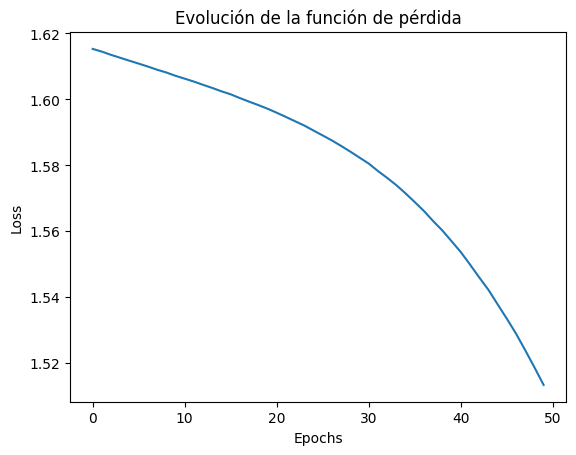

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Modelo mejorado (puedes ajustar si quieres)
model = nn.Sequential(
    nn.Linear(input_size, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 50
loss_history = []

# Medir tiempo
start_time = time.time()

# ENTRENAMIENTO
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # Mostrar progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

training_time = time.time() - start_time

# EVALUACIÓN
model.eval()
with torch.no_grad():
    preds = model(X_test_t)
    preds = torch.argmax(preds, axis=1)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average="weighted", zero_division=0)
recall = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

# RESULTADOS
print("\nRESULTADOS:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Tiempo:", training_time)

# GRÁFICA DE LOSS
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Evolución de la función de pérdida")
plt.show()

---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Función para crear arquitecturas
def crear_modelo(tipo):

    if tipo == 1:
        return nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    elif tipo == 2:
        return nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    elif tipo == 3:
        return nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    elif tipo == 4:
        return nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    elif tipo == 5:
        return nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

resultados = []

# Entrenar las 5 arquitecturas
for i in range(1, 6):

    model = crear_modelo(i)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    epochs = 50

    start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        loss.backward()
        optimizer.step()

    tiempo = time.time() - start

    # Evaluación
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t)
        preds = torch.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    resultados.append([
        f"Arquitectura {i}",
        round(acc, 3),
        round(prec, 3),
        round(rec, 3),
        round(f1, 3),
        round(tiempo, 2)
    ])

# Crear DataFrame
df = pd.DataFrame(resultados, columns=[
    "Arquitectura", "Accuracy", "Precision", "Recall", "F1-score", "Tiempo (s)"
])

# Mostrar tabla
print(df)

# Convertir automáticamente a Markdown
print("\nTabla en Markdown:\n")
print(df.to_markdown(index=False))

     Arquitectura  Accuracy  Precision  Recall  F1-score  Tiempo (s)
0  Arquitectura 1     0.450      0.777   0.450     0.414        4.08
1  Arquitectura 2     0.399      0.412   0.399     0.276        7.65
2  Arquitectura 3     0.452      0.745   0.452     0.373       21.14
3  Arquitectura 4     0.512      0.663   0.512     0.425       11.19
4  Arquitectura 5     0.515      0.697   0.515     0.372       29.01

Tabla en Markdown:

| Arquitectura   |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo (s) |
|:---------------|-----------:|------------:|---------:|-----------:|-------------:|
| Arquitectura 1 |      0.45  |       0.777 |    0.45  |      0.414 |         4.08 |
| Arquitectura 2 |      0.399 |       0.412 |    0.399 |      0.276 |         7.65 |
| Arquitectura 3 |      0.452 |       0.745 |    0.452 |      0.373 |        21.14 |
| Arquitectura 4 |      0.512 |       0.663 |    0.512 |      0.425 |        11.19 |
| Arquitectura 5 |      0.515 |       0.697 |    0.515 

---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---


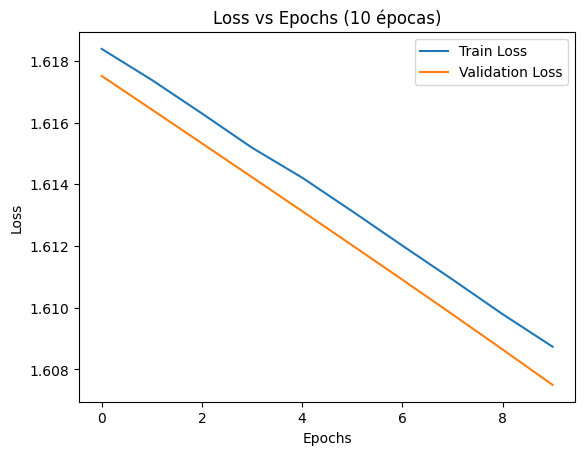

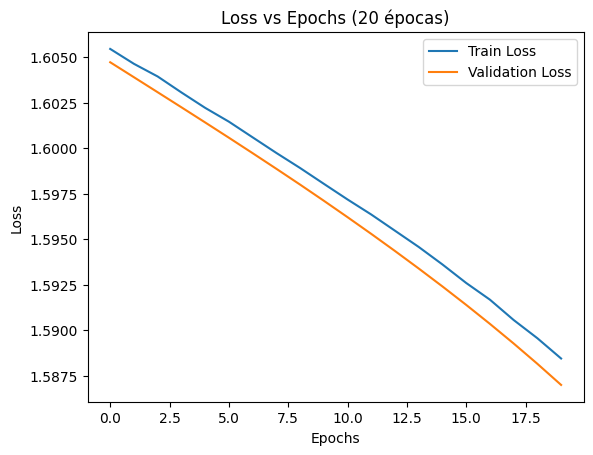

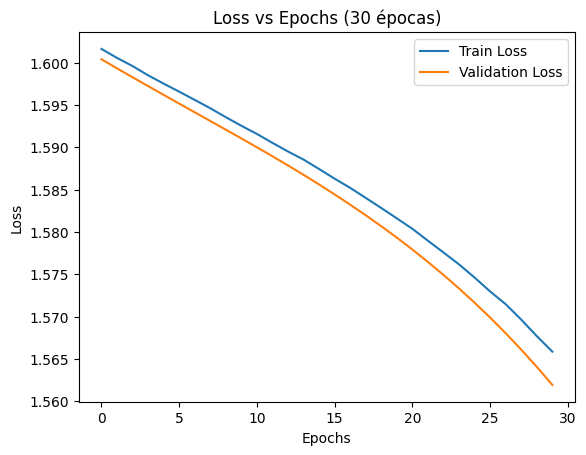

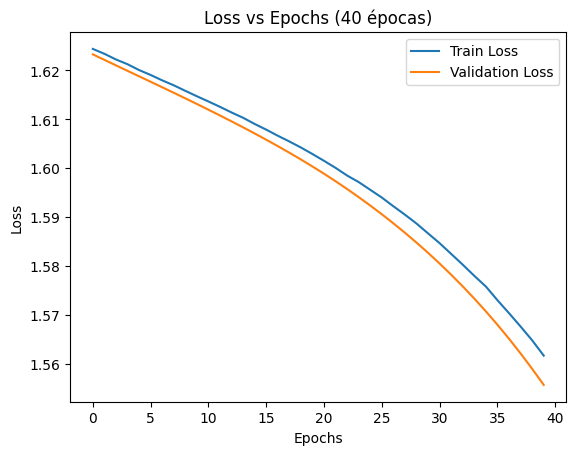

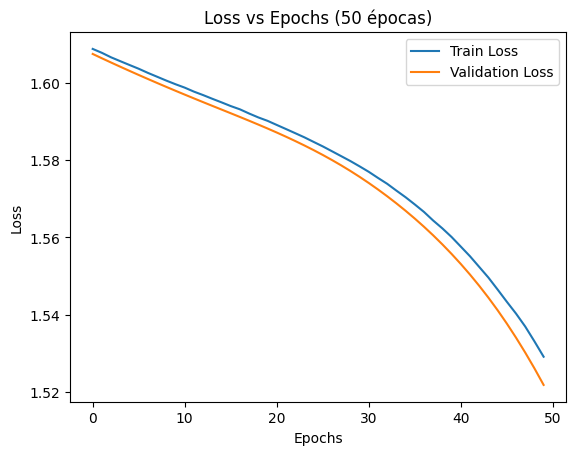

   Épocas  Accuracy  Precision  Recall  F1-score  Tiempo (s)
0      10     0.221      0.049   0.221     0.080        5.87
1      20     0.354      0.499   0.354     0.292       12.63
2      30     0.403      0.418   0.403     0.284       19.49
3      40     0.476      0.474   0.476     0.320       25.51
4      50     0.434      0.541   0.434     0.351       31.75

Tabla en Markdown:

|   Épocas |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo (s) |
|---------:|-----------:|------------:|---------:|-----------:|-------------:|
|       10 |      0.221 |       0.049 |    0.221 |      0.08  |         5.87 |
|       20 |      0.354 |       0.499 |    0.354 |      0.292 |        12.63 |
|       30 |      0.403 |       0.418 |    0.403 |      0.284 |        19.49 |
|       40 |      0.476 |       0.474 |    0.476 |      0.32  |        25.51 |
|       50 |      0.434 |       0.541 |    0.434 |      0.351 |        31.75 |


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Definir la MEJOR arquitectura (usa la que te dio mejor F1 en Paso 6)
def mejor_modelo():
    return nn.Sequential(
        nn.Linear(input_size, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )

epochs_list = [10, 20, 30, 40, 50]
resultados = []

# Probar diferentes épocas
for epocas in epochs_list:

    model = mejor_modelo()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_losses = []
    val_losses = []

    start = time.time()

    # Entrenamiento
    for epoch in range(epocas):

        # TRAIN
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # VALIDATION
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)
            val_losses.append(val_loss.item())

    tiempo = time.time() - start

    # Evaluación en TEST
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t)
        preds = torch.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    resultados.append([
        epocas,
        round(acc, 3),
        round(prec, 3),
        round(rec, 3),
        round(f1, 3),
        round(tiempo, 2)
    ])

    # GRÁFICA (una por cada configuración)
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Loss vs Epochs ({epocas} épocas)")
    plt.legend()
    plt.show()

# Tabla de resultados
df = pd.DataFrame(resultados, columns=[
    "Épocas", "Accuracy", "Precision", "Recall", "F1-score", "Tiempo (s)"
])

print(df)

# Tabla en Markdown
print("\nTabla en Markdown:\n")
print(df.to_markdown(index=False))


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|---------|----------|--------|----------|-----------------------------|
| 10 | 0.221 | 0.049 | 0.221 | 0.080 | 5.9 |
| 20 | 0.354 | 0.499 | 0.354 | 0.292 | 12.6 |
| 30 | 0.403 | 0.418 | 0.403 | 0.284 | 19.5 |
| 40 | 0.476 | 0.474 | 0.476 | 0.320 | 25.5 |
| 50 | 0.434 | 0.541 | 0.434 | 0.351 | 31.8 |

---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**

La mejor Arquitectura es la 5 porque tiene accuracy más alto 0.515 y precision buena 0.697

2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**

La Arquitectura 2 fue claramente la de peor desempeño en todas las métricas (Accuracy: 0.399, F1-score: 0.276).

3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**

El número de capas ocultas define la capacidad de abstracción de la red.

4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**

La mejor cantidad para entrenar el modelo fue de 40 épocas.

Esta elección se justifica porque en este punto el modelo alcanza su rendimiento máximo en Accuracy (0.476) y mantiene un equilibrio sólido en las demás métricas.

5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**

Se detectó subajuste en las 10 épocas, identificado por un Accuracy muy bajo (0.221) y una Precision de apenas 0.049, lo que indica que el modelo no entrenó lo suficiente para capturar la estructura de los datos.

6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**

Entre las 20 y 30 épocas

7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**

la Arquitectura 5 fue la más precisa únicamente en términos de Accuracy (0.515).

De estos resultados se pueden sacar las siguientes conclusiones:

La precisión no lo es todo: Aunque la Arquitectura 5 tiene el Accuracy más alto, su F1-score (0.372) es notablemente inferior al de la Arquitectura 4 (0.425).

8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**

En este contexto, la métrica más importante es el F1-score.

La razón principal es que el Accuracy puede ser engañoso, especialmente si los datos están desbalanceados

---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

